In [1]:
%matplotlib widget
import mcstasscript as ms


def make_trex(L0=2.4, RRM=18, r='"HR"'):
    trex = ms.McStas_instr(
        "TRex_choppers", author="Bing Li", output_path="trex_choppers"
    )
    trex.settings(suppress_output=True)

    # ------------------- instrument parameters -------------------
    L0 = trex.add_parameter(
        "L0",
        value=L0,
        comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
        + "for the source component by adding and subtracting a set wavelength",
    )

    RRM = trex.add_parameter(
        "int",
        "RRM",
        value=RRM,
        comment="repetition rate multiplication",
    )

    r = trex.add_parameter(
        "string",
        "r",
        value=r,
        comment="HR for High Resolution, HF for High Flux",
    )

    # ------------------- Declare -------------------
    trex.add_declare_var(
        "double",
        "T_offset",
        value=1.7e-3,
        comment="Time offset in [s] to shift to the center of long pulse",
    )
    trex.add_declare_var(
        "double",
        "f",
        value=14.0,
        comment="Source frequency in [Hz]",
    )
    # ------------------- More declare -------------------
    trex.append_declare("""

    double tof_BW1, tof_BW2, tof_P1, tof_P2, tof_M1, tof_M2;

    // characteristic wavelength
    double v0;

    // distances
    double L_BW1 = 32;
    double L_BW2 = 40;
    double L_P1 = 107.95;
    double L_P2 = 108.05;
    double L_M1 = 161.995;
    double L_M2 = 162.005;

    """)

    # ------------------- More declare -------------------

    trex.append_declare("""

    double f_slow = 0.0001;

    // BW1 Chopper
    double f_BW1;
    double phase_BW1;// angular delay

    double radius_BW1 = 0.35;
    double slit_height_BW1 = 0.095; // FIXME
    double nslits_BW1 = 1;
    double theta_pos_BW1 = 0;
    double theta_width_BW1 = 61.4;

    // BW2 Chopper
    double f_BW2;
    double phase_BW2;// angular delay

    double radius_BW2 = 0.35;
    double slit_height_BW2 = 0.095; // FIXME
    double nslits_BW2 = 1;
    double theta_pos_BW2 = 0;
    double theta_width_BW2 = 63.3;

    // P1 Chopper
    double f_P1;
    double phase_P1;// angular delay

    double radius_P1 = 0.35;
    double slit_height_P1 = 0.095;
    double nslits_P1 = 2;
    double theta_pos_P1_HR = 0;
    double theta_pos_P1_HF = -55;
    double theta_width_P1_HR = 20;
    double theta_width_P1_HF = 35;

    // P2 Chopper
    double f_P2;
    double phase_P2;// angular delay

    double radius_P2 = 0.35;
    double slit_height_P2 = 0.095;
    double nslits_P2 = 2;
    double theta_pos_P2_HR = 0;
    double theta_pos_P2_HF = -55;
    double theta_width_P2_HR = 20;
    double theta_width_P2_HF = 35;



    // M1 Chopper
    double f_M1;
    double phase_M1;// angular delay

    double radius_M1 = 0.35;
    double slit_height_M1 = 0.045; 
    double nslits_M1 = 1;
    double theta_pos_M1_HR = 180;
    double theta_pos_M1_HF = 5;
    double theta_width_M1_HR = 2.5;
    double theta_width_M1_HF = 4.3;


    // M2 Chopper
    double f_M2;
    double phase_M2;// angular delay

    double radius_M2 = 0.35;
    double slit_height_M2 = 0.045; 
    double nslits_M2 = 1;
    double theta_pos_M2_HR = 0;
    double theta_pos_M2_HF = -175;
    double theta_width_M2_HR = 2.5;
    double theta_width_M2_HF = 4.3;

    """)
    # ------------------- Initialize -------------------
    trex.append_initialize("""
    // frequencies

    // f = f_slow;

    f_BW1 = f;
    f_BW2 = f_BW1;
    f_P1 = RRM*f*0.75;
    f_P2 = -f_P1;
    f_M1 = RRM*f;
    f_M2 = -f_M1;

    //TODO
    // Resolution Settings
    //"angular offset for the P-Chopper {0: 20deg Opening, 55: 35deg Opening}",
    // angular offset for the M-Chopper {0: 2.5deg Opening, 177: 4,3deg Opening}
    //if (strcmp(r,"HR") == 0){
    //
    //} else if (strcmp(r,"HF") == 0){
    //
    //} else {
    //    printf("Need valid resolution option, 'HR' or 'HF'");
    //}


    // characteristic wavelength 

    v0 = 2*PI*K2V/L0;       // speed center neutron


    // time of flight and chopper phases
    tof_BW1 = T_offset + L_BW1/v0;
    tof_BW2 = T_offset + L_BW2/v0;
    tof_P1 = T_offset + L_P1/v0;
    tof_P2 = T_offset + L_P2/v0;
    tof_M1 = T_offset + L_M1/v0;
    tof_M2 = T_offset + L_M2/v0;

    /* Chopper parameters */
    phase_BW1 = tof_BW1 * f_BW1 * 360;  //+ theta_pos_BW1; 
    phase_BW2 = tof_BW2 * f_BW2 * 360;  //+ theta_pos_BW2; 
    phase_P1 = tof_P1 * f_P1 * 360;  //+ theta_pos_P1_HR; 
    phase_P2 = tof_P2 * f_P2 * 360;
    phase_M1 = tof_M1 * f_M1 * 360;
    phase_M2 = tof_M2 * f_M2 * 360;




    """)

    return trex

In [2]:
import math
import os
import shutil
import glob


def illuminate_chopper(instrument, chopper):

    pos = chopper.AT_data
    rot = chopper.ROTATED_data
    radius = chopper.radius

    if isinstance(rot, str):
        print("TODO: rotation is a string.")
    elif isinstance(rot, list):
        if math.isclose(rot[2], 0):
            shift = "-1"
        elif math.isclose(rot[2], 180):
            shift = "1"
        else:
            raise ValueError(f"Rotation anlge {rot[2]} is not 0 or 180.")
    else:
        raise ValueError(f"Type of chopper radius {radius} not recogonized.")

    if isinstance(radius := chopper.radius, str):
        source_pos = [pos[0], shift + " * " + radius, pos[2] - 0.01]
        xwidth = radius + "* 2.5"
        yheight = radius + "* 2.5"
    elif isinstance(radius, (int, float)):
        source_pos = [pos[0], int(shift) * radius, pos[2] - 0.01]
        xwidth = radius * 2.5
        yheight = radius * 2.5
    else:
        raise ValueError(f"Type of chopper radius {radius} not recogonized.")

    # Use Source_div, all neutrons are created at t=0
    source = instrument.add_component(
        "Source",
        "Source_div",
        AT=source_pos,
    )
    source.set_parameters(
        xwidth=xwidth,
        yheight=yheight,
        focus_ah=0.001,
        focus_aw=0.001,
        E0=5,
        dE=0.1,
    )
    instrument.move_component(source, before=chopper)

    PSD = instrument.add_component(
        "PSD", "PSD_monitor", AT=[0, 0, 0.5], RELATIVE=source
    )
    PSD.set_parameters(xwidth=source.xwidth, yheight=source.yheight, nx=300, ny=300)

    try:
        instrument.check_for_errors()
    except Exception as e:
        print(str(e))

    data = instrument.backengine()

    # instrument.remove_component(source)
    # instrument.remove_component(PSD)

    base_path = os.path.join(os.getcwd(), trex.output_path)
    for path in glob.glob(base_path) + glob.glob(base_path + "_[0-9]*"):
        if os.path.isdir(path):
            shutil.rmtree(path)

    return data

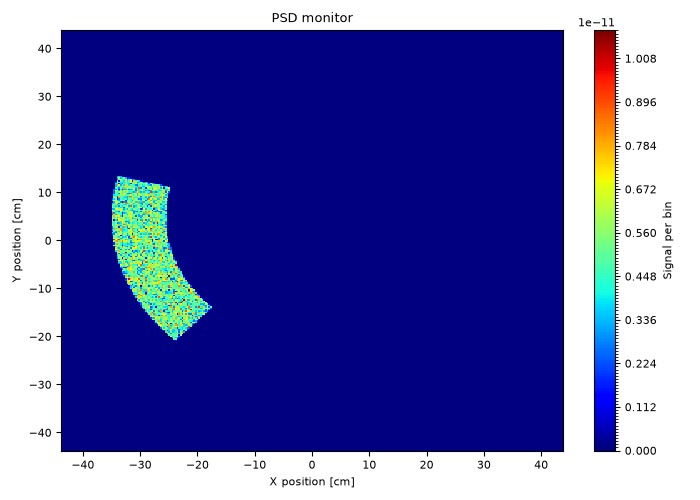

In [3]:
trex = make_trex()

BW_Chopper_1 = trex.add_component(
    "BW_Chopper_1",
    "DiskChopper",
    AT=[0.011348994153930106, 0.0, 32.0],
    ROTATED=[0, 0.124542024141650, 0],
    comment="Bandwidth chopper 1",
)

BW_Chopper_1.set_parameters(
    theta_0="theta_width_BW1",
    radius="radius_BW1",
    yheight="slit_height_BW1",
    nu="f_BW1",
    phase="phase_BW1 + theta_pos_BW1",
    nslit="nslits_BW1",
)

data = illuminate_chopper(trex, BW_Chopper_1)
ms.make_sub_plot(data, fontsize=8, aspects="equal")

In [4]:
trex.show_instrument(backend="pythreejs")

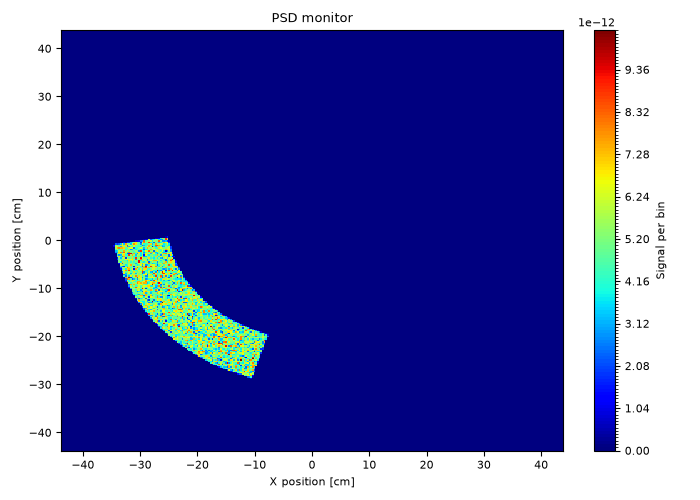

In [5]:
trex = make_trex()

BW_Chopper_2 = trex.add_component(
    "BW_Chopper_2",
    "DiskChopper",
    AT=[0.03140505829452013, 0.0, 40.0],
    ROTATED=[0, 0.162739331227240, 0],
    comment="Bandwidth chopper 2",
)

BW_Chopper_2.set_parameters(
    theta_0="theta_width_BW2",
    radius="radius_BW2",
    yheight="slit_height_BW2",
    nu="f_BW2",
    phase="phase_BW2 + theta_pos_BW2",
    nslit="nslits_BW2",
)

data = illuminate_chopper(trex, BW_Chopper_2)
ms.make_sub_plot(data, fontsize=8, aspects="equal")

In [6]:
trex.show_instrument(backend="pythreejs")

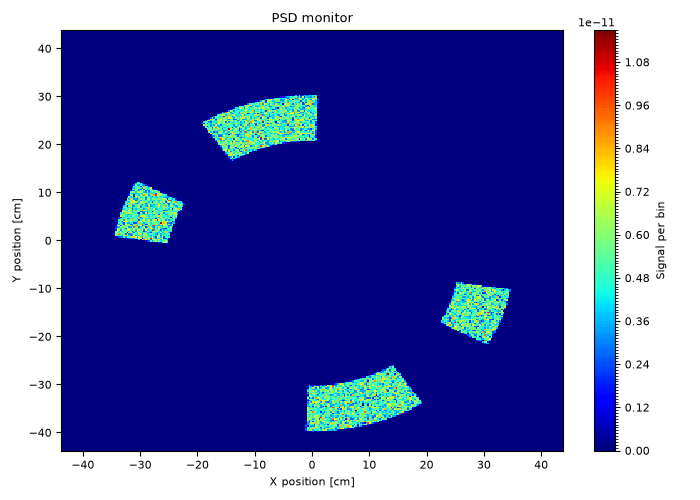

In [17]:
trex = make_trex()

PulseShapingChopper1_HR = trex.add_component(
    "PulseShapingChopper1_HR",
    "DiskChopper",
    AT=[0.4108460115539497, 0.0, 107.95],
    ROTATED=[0, 0.430122381481144, 180],
    comment="/* ---------------------- P-Choppers -------------------- */",
)
PulseShapingChopper1_HR.set_GROUP("PulseShapingChopper1")

PulseShapingChopper1_HR.set_parameters(
    theta_0="theta_width_P1_HR",
    radius="radius_P1",
    yheight="slit_height_P1",
    nu="f_P1",
    phase="phase_P1 + theta_pos_P1_HR",
    nslit=2,
)
PulseShapingChopper1_HF = trex.add_component(
    "PulseShapingChopper1_HF",
    "DiskChopper",
    AT=[0.4108460115539497, 0.0, 107.95],
    ROTATED=[0, 0.430122381481144, 180],
    GROUP="PulseShapingChopper1",
)

PulseShapingChopper1_HF.set_parameters(
    theta_0="theta_width_P1_HF",
    radius="radius_P1",
    yheight="slit_height_P1",
    nu="f_P1",
    phase="phase_P1 + theta_pos_P1_HF",
    nslit=2,
)

data = illuminate_chopper(trex, PulseShapingChopper1_HR)
ms.make_sub_plot(data, fontsize=8, aspects="equal")

In [18]:
trex.show_instrument(backend="pythreejs")

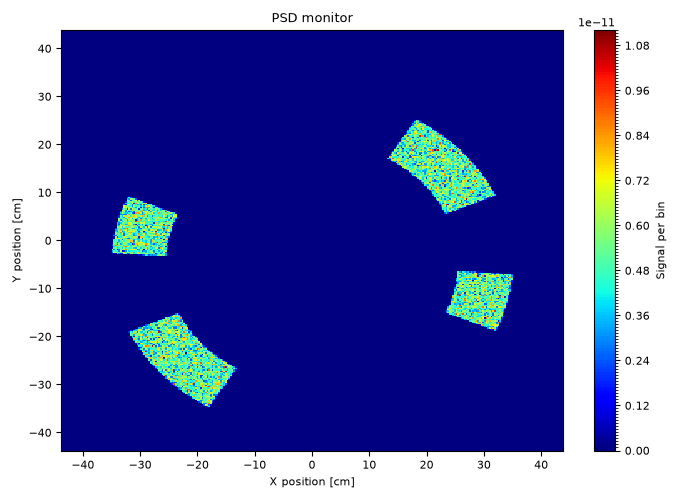

In [15]:
trex = make_trex()

PulseShapingChopper2_HR = trex.add_component(
    "PulseShapingChopper2_HR",
    "DiskChopper",
    AT=[0.41159673083080733, 0.0, 108.055],
    ROTATED=[0, 0.430122381481144, 180],
)
PulseShapingChopper2_HR.set_GROUP("PulseShapingChopper2")

PulseShapingChopper2_HR.set_parameters(
    theta_0="theta_width_P2_HR",
    radius="radius_P2",
    yheight="slit_height_P2",
    nu="f_P2",
    phase="phase_P2 + theta_pos_P2_HR",
    nslit=2,
)
PulseShapingChopper2_HF = trex.add_component(
    "PulseShapingChopper2_HF",
    "DiskChopper",
    AT=[0.41159673083080733, 0.0, 108.055],
    ROTATED=[0, 0.430122381481144, 180],
    GROUP="PulseShapingChopper2",
)

PulseShapingChopper2_HF.set_parameters(
    theta_0="theta_width_P2_HF",
    radius="radius_P2",
    yheight="slit_height_P2",
    nu="f_P2",
    phase="phase_P2 + theta_pos_P2_HF",
    nslit=2,
)


data = illuminate_chopper(trex, PulseShapingChopper2_HR)
ms.make_sub_plot(data, fontsize=8, aspects="equal")

In [16]:
trex.show_instrument(backend="pythreejs")

In [11]:
# MonoChopper1_HR = trex.add_component(
#     "MonoChopper1_HR",
#     "DiskChopper",
#     AT=[0.8166097806955753, 0.0, 161.995],
#     ROTATED=[0, 0.430122381481144, 180],
#     comment="/* ---------------------- M-Choppers -------------------- */",
# )
# MonoChopper1_HR.set_GROUP("MonoChopper1")

# MonoChopper1_HR.set_parameters(
#     theta_0="theta_width_M1_HR",
#     radius="radius_M1",
#     yheight="slit_height_M1",
#     nu="f_M1",
#     delay="delay_M1_HR",
#     nslit="nslits_M1",
# )
# MonoChopper1_HF = trex.add_component(
#     "MonoChopper1_HF",
#     "DiskChopper",
#     AT=[0.8166097806955753, 0.0, 161.995],
#     ROTATED=[0, 0.430122381481144, 180],
#     GROUP="MonoChopper1",
# )

# MonoChopper1_HF.set_parameters(
#     theta_0="theta_width_M1_HF",
#     radius="radius_M1",
#     yheight="slit_height_M1",
#     nu="f_M1",
#     delay="delay_M1_HF",
#     nslit="nslits_M1",
# )

# M1_PSD = trex.add_component(
#     "M1_PSD", "PSD_monitor", AT=[0, -0.35, 0.01], RELATIVE="PREVIOUS"
# )
# M1_PSD.set_parameters(xwidth=1, yheight=1, nx=300, ny=300)

In [12]:
# MonoChopper2_HR = trex.add_component(
#     "MonoChopper2_HR",
#     "DiskChopper",
#     AT=[0.8166097806955753, 0.0, 162.005],
#     ROTATED=[0, 0.430122381481144, 0],
# )
# MonoChopper2_HR.set_GROUP("MonoChopper2")

# MonoChopper2_HR.set_parameters(
#     theta_0="theta_width_M2_HR",
#     radius="radius_M2",
#     yheight="slit_height_M2",
#     nu="f_M2",
#     delay="delay_M2_HR",
#     nslit="nslits_M2",
# )
# MonoChopper2_HF = trex.add_component(
#     "MonoChopper2_HF",
#     "DiskChopper",
#     AT=[0.8166097806955753, 0.0, 162.005],
#     ROTATED=[0, 0.430122381481144, 0],
#     GROUP="MonoChopper2",
# )

# MonoChopper2_HF.set_parameters(
#     theta_0="theta_width_M2_HF",
#     radius="radius_M2",
#     yheight="slit_height_M2",
#     nu="f_M2",
#     delay="delay_M2_HF",
#     nslit="nslits_M2",
# )
# M2_PSD = trex.add_component(
#     "M2_PSD", "PSD_monitor", AT=[0, -0.35, 0.01], RELATIVE="PREVIOUS"
# )
# M2_PSD.set_parameters(xwidth=1, yheight=1, nx=300, ny=300)

In [13]:
trex.show_instrument(backend="pythreejs")

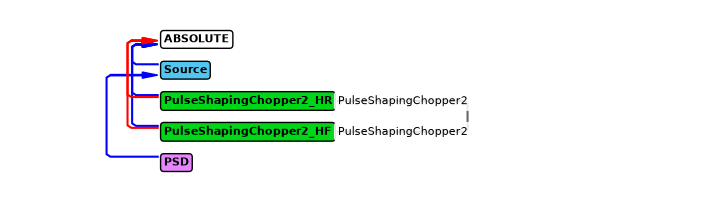

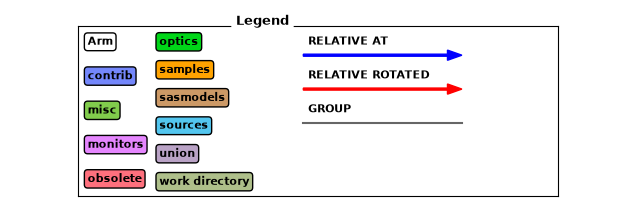

In [14]:
# trex.show_diagram(variable="l", limits=[0.8, 3.5])
trex.show_diagram(analysis=False)